## Synthetic Dataset Generation Process (Azure OpenAI API)

In this section, we automatically create a **synthetic issue dataset** representing the daily operations of a technology consulting firm.  
The goal is to simulate realistic internal tickets across five key departments:
**Data & AI**, **Marketing**, **Cybersecurity**, **Cloud Infrastructure**, and **IT Operations**.


In [33]:
import os
import json
import random
import pandas as pd
from tqdm import tqdm
from openai import AzureOpenAI

# --- Azure OpenAI setup ---
client = AzureOpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    api_version=os.getenv("OPENAI_API_VERSION"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
)

MODEL_NAME = os.getenv("OPENAI_DEPLOYMENT_ID")

# --- Parameters ---
TEMPERATURE = 0.7
N_PER_DEPT = 200
MAX_TOKENS = 900
OUTPUT_PATH = "data/sample_issues.csv"

# --- Departments & Descriptions ---
DEPARTMENTS = {
    "Data & AI": "Data engineering, analytics, and machine learning — pipelines, dashboards, model drift, and data quality issues.",
    "Cloud Infrastructure": "Cloud deployments, scaling, cost optimization, and system monitoring.",
    "Cybersecurity": "Access control, certificates, endpoint protection, and incident monitoring.",
    "IT Operations": "Incident management, performance monitoring, system alerts, and maintenance.",
    "Marketing": "Campaign tracking, content updates, lead management, and web analytics."
}

random.seed(42)


###  Overview of the Process

1. **Target setup**
   - We generate **200 synthetic issues per department**, for a total of **1,000 issues**.
   - Each record includes:
     - `issue_id`: Unique ticket identifier (e.g., `TCKT-0371`)
     - `description`: Human-like summary of the issue
     - `category`: Department or area (target class for classification)
     - `priority`: One of `High`, `Medium`, or `Low`
     - `created_at`: Random date within the current year

In [40]:
import datetime as dt
import random

def generate_issues_azure(domain, description, n_samples=N_PER_DEPT):
    """Generate synthetic issues using Azure OpenAI with clean text output and realistic metadata."""
    
    # --- Build user prompt ---
    user_prompt = f"""
        Department: {domain}
        Context: {description}

        Generate {n_samples} unique issue tickets for this department.
        Each issue should:
        - Be realistic and sound human-written
        - Describe a real operational problem or request (1–2 sentences)
        - Avoid lists, bullet points, or prefixes like 'text:' or 'label:'
        - Reflect the department’s daily work context

        Write each issue as a plain sentence, one per line.
        Do NOT include JSON formatting, field names, or labels — only the issue text itself.
        """

    # --- Azure ChatCompletion ---
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an expert text generator that writes realistic and diverse issue reports "
                    "for enterprise teams. Write plain sentences without any formatting or keys."
                ),
            },
            {"role": "user", "content": user_prompt},
        ],
        temperature=TEMPERATURE,
        max_tokens=MAX_TOKENS,
    )

    output = response.choices[0].message.content
    rows = []

    # --- Helper: random date within the current year ---
    def random_date_this_year():
        """Generate a random datetime within the current year."""
        year = dt.datetime.now().year
        start_date = dt.datetime(year, 1, 1)
        end_date = dt.datetime(year, 12, 31, 23, 59, 59)
        delta = end_date - start_date
        random_second = random.randint(0, int(delta.total_seconds()))
        rand_dt = start_date + dt.timedelta(seconds=random_second)
        return rand_dt.strftime("%Y-%m-%d %H:%M:%S")

    priorities = ["High", "Medium", "Low"]

    # --- Parse model output safely ---
    for line in output.splitlines():
        # Clean line and skip empties
        text = line.strip("•- ").strip()
        if len(text) <= 10:
            continue

        issue_number = len(rows) + 1
        ticket_id = f"TCKT-{issue_number:04d}"  # e.g., TCKT-0001

        rows.append({
            "issue_id": ticket_id,
            "description": text,
            "category": domain,
            "priority": random.choices(priorities, weights=[0.2, 0.5, 0.3])[0],
            "created_at": random_date_this_year()
        })

    return rows


2. **Batch generation with retries**
   - To make generation more stable, issues are created in **batches of 40** (controlled by `BATCH_SIZE`).
   - For each department, the model runs up to **6 batches** (`MAX_RETRIES = 6`) until it reaches the target of 200 issues.
   - Each batch call is **logged** to track how many valid responses were returned.

3. **Post-processing**
   - Remove very short or empty descriptions (`< 20 characters`).
   - Drop duplicate issues that might have been generated across batches.
   - Reset the index for a clean dataset.

4. **Summary and storage**
   - The cleaned dataset is saved to:  
     `data/sample_issues.csv`
   - A brief summary is printed:
     - Number of issues per category
     - Priority distribution
     - Average text length per category

In [ ]:
# --- Generate a balanced synthetic dataset with multiple batches per department ---
import pandas as pd
import os
from tqdm import tqdm
import time

# --- Target setup ---
N_PER_DEPT = 200        # total desired per department
BATCH_SIZE = 40         # issues per batch
MAX_RETRIES = 6         # generate up to this many batches if needed

tickets = []

print(f" Target: {len(DEPARTMENTS)} departments × {N_PER_DEPT} samples each = {len(DEPARTMENTS) * N_PER_DEPT} total issues\n")

for dept, desc in DEPARTMENTS.items():
    dept_rows = []
    print(f"\n Generating issues for department: {dept}")
    
    for i in range(MAX_RETRIES):
        if len(dept_rows) >= N_PER_DEPT:
            break  # stop if we already reached target
        print(f" Batch {i+1}: requesting {BATCH_SIZE} samples...")

        batch = generate_issues_azure(dept, desc, n_samples=BATCH_SIZE)
        dept_rows.extend(batch)
        print(f" Returned {len(batch)} issues (total so far: {len(dept_rows)})")
        
        # Small pause to avoid rate limits
        time.sleep(1)
    
    # Trim or pad (if necessary) to get exactly N_PER_DEPT
    dept_rows = dept_rows[:N_PER_DEPT]
    tickets.extend(dept_rows)
    print(f" Final count for {dept}: {len(dept_rows)} issues\n")

# --- Convert to DataFrame ---
df = pd.DataFrame(tickets)[["issue_id", "description", "category", "priority", "created_at"]]

# --- Clean and filter ---
df = (
    df[df["description"].str.len() > 20]              # remove too-short entries
    .drop_duplicates(subset=["description"])          # drop duplicates
    .reset_index(drop=True)
)

output_path = "../data/sample_issues.csv"
df.to_csv(output_path, index=False, encoding="utf-8")

# --- Summary output ---
print(f"\n Synthetic dataset created with {len(df)} issues.")
print(f" Saved to: {output_path}\n")

print("Category distribution:")
print(df["category"].value_counts(), "\n")

print("Priority distribution:")
print(df["priority"].value_counts(normalize=True).round(2), "\n")

print("Average text length per category:")
print(df.groupby('category')["description"].apply(lambda x: round(x.str.split().apply(len).mean(), 2)))

# --- Show a small random sample ---
df.sample(5, random_state=42)


 Target: 5 departments × 200 samples each = 1000 total issues


 Generating issues for department: Data & AI
 Batch 1: requesting 40 samples...
 Returned 40 issues (total so far: 40)
 Batch 2: requesting 40 samples...
 Returned 40 issues (total so far: 80)
 Batch 3: requesting 40 samples...
 Returned 40 issues (total so far: 120)
 Batch 4: requesting 40 samples...
 Returned 40 issues (total so far: 160)
 Batch 5: requesting 40 samples...
 Returned 40 issues (total so far: 200)
 Final count for Data & AI: 200 issues


 Generating issues for department: Cloud Infrastructure
 Batch 1: requesting 40 samples...
 Returned 40 issues (total so far: 40)
 Batch 2: requesting 40 samples...
 Returned 40 issues (total so far: 80)
 Batch 3: requesting 40 samples...
 Returned 40 issues (total so far: 120)
 Batch 4: requesting 40 samples...
 Returned 39 issues (total so far: 159)
 Batch 5: requesting 40 samples...
 Returned 40 issues (total so far: 199)
 Batch 6: requesting 40 samples...
 Returned 40 

,issue_id,description,category,priority,created_at
521,TCKT-0002,An employee reported receiving a suspicious em...,Cybersecurity,Medium,2025-10-11 19:12:30
737,TCKT-0018,The remote access software is not functioning ...,IT Operations,Low,2025-08-26 10:29:07
740,TCKT-0021,The SSL certificates on several web services h...,IT Operations,High,2025-10-17 11:06:12
660,TCKT-0021,Unauthorized access attempts have increased si...,IT Operations,Low,2025-07-12 16:13:59
411,TCKT-0012,Several endpoints are not receiving timely upd...,Cybersecurity,Medium,2025-07-18 09:13:58


## How We Evaluate Intra-Cluster Variance

To understand how diverse or repetitive the generated issues are within each department,
we measure **intra-cluster variance** in embedding space.  
Here’s the process:

- **1️ Convert text into embeddings**  
  Each issue description is transformed into a numerical vector using a sentence embedding model  
  (`all-MiniLM-L6-v2`). This lets us measure similarity between texts.

- **2️ Group issues by department (category)**  
  We treat each department as a cluster — for example, “Data & AI” or “Marketing”.

- **3 Find each cluster’s center**  
  We compute the *average embedding* for each department, which acts as the cluster’s centroid.

- **4️ Measure how spread out each cluster is**  
  We calculate the average squared distance of all issue vectors from their cluster’s center.  
  This number represents **intra-cluster variance**.

- **5️ Interpret the results**  
  - A **low variance** means the issues use similar wording or style (less diversity).  
  - A **high variance** means the issues are linguistically diverse (greater variety).

This gives us a quantitative way to check if our synthetic data feels natural and varied —
rather than being repetitive or overly uniform.


,category,intra_cluster_variance
3,IT Operations,0.774266
4,Marketing,0.760948
0,Data & AI,0.756199
2,Cybersecurity,0.741213
1,Cloud Infrastructure,0.683945


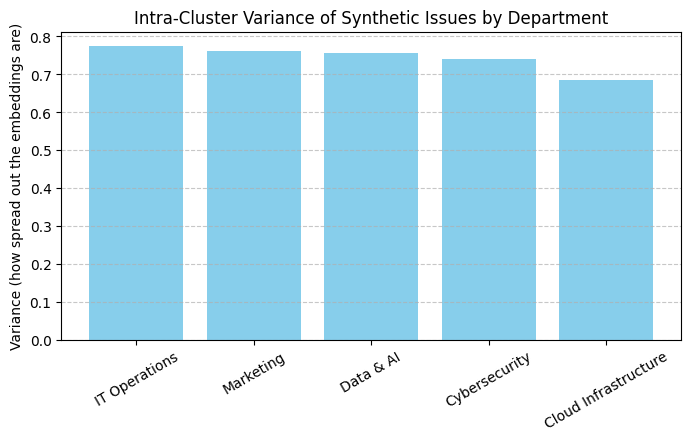

In [42]:
# -------------------------------------------------------------------
# Step 1: Load a sentence-embedding model
# -------------------------------------------------------------------
# We’ll turn each issue’s text into a numeric vector so we can
# measure how similar or different the issues are in meaning.
# "all-MiniLM-L6-v2" is a compact model that captures sentence meaning well.
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------------------------------------------------
# Step 2: Create embeddings for every issue
# -------------------------------------------------------------------
# Each issue description becomes a vector of numbers.
# Setting normalize_embeddings=True scales all vectors to the same length
# so distance comparisons between them are fair.
embeddings = embedder.encode(
    df["description"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True
)

# Store these vectors back into the dataframe
df["embedding"] = list(embeddings)

# -------------------------------------------------------------------
# Step 3: Measure "intra-cluster variance" inside each department
# -------------------------------------------------------------------
# For each department (domain), we’ll see how spread out its issues are
# in embedding space.  Larger values mean the language varies more.
variance_results = []

for category in df["category"].unique():
    # Take only the embeddings for this department
    cluster_embs = np.stack(df.loc[df["category"] == category, "embedding"].values)
    
    # Compute the average embedding — the “center” of that department’s cluster
    mean_emb = cluster_embs.mean(axis=0)
    
    # Measure how far each issue vector is from the center (squared distance)
    # and take the average.  That’s our intra-cluster variance.
    intra_var = np.mean(np.sum((cluster_embs - mean_emb) ** 2, axis=1))
    
    # Save the result so we can compare departments later
    variance_results.append({
        "category": category,
        "intra_cluster_variance": intra_var
    })

# -------------------------------------------------------------------
# Step 4: Summarize the results
# -------------------------------------------------------------------
# Turn the list of variances into a small summary table,
# sorted from most to least diverse.
var_df = (
    pd.DataFrame(variance_results)
      .sort_values("intra_cluster_variance", ascending=False)
)

display(var_df)

# -------------------------------------------------------------------
# Step 5: Visualize for easier comparison
# -------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.bar(var_df["category"], var_df["intra_cluster_variance"], color="skyblue")
plt.title("Intra-Cluster Variance of Synthetic Issues by Department")
plt.ylabel("Variance (how spread out the embeddings are)")
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
